In [1]:
!pip install -q diffusers transformers xformers git+https://github.com/huggingface/accelerate.git &> /dev/null

In [2]:
!pip install -q opencv-contrib-python &> /dev/null
!pip install -q controlnet_aux &> /dev/null

In [3]:
!pip install -q peft &> /dev/null

## Импорты

In [4]:
from diffusers import StableDiffusionControlNetPipeline
from diffusers.utils import load_image
import cv2
from PIL import Image
import numpy as np
from diffusers import StableDiffusionControlNetPipeline, ControlNetModel
import torch
from diffusers import UniPCMultistepScheduler

The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

2024-04-11 19:20:35.953591: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-04-11 19:20:35.953695: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-04-11 19:20:36.084565: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


## Референс

Загрузим [референс](https://portrets.ru/hudozhniki/venecianov/devushka-v-platke-kartina.html)

In [5]:
image = load_image("https://portrets.ru/hudozhniki/venecianov/devushka-v-platke-kartina.jpg")

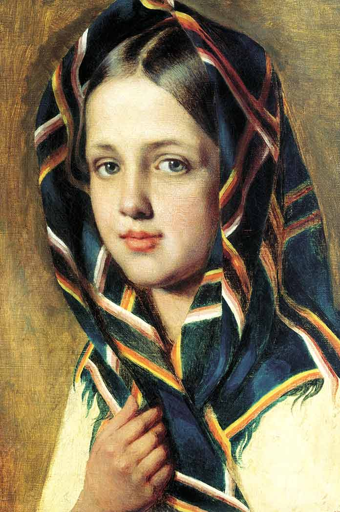

In [6]:
size = (340, 512)
image = image.resize(size)
image

Переведем изображение в контуры

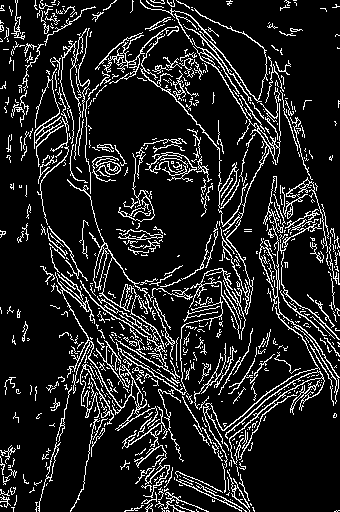

In [7]:
image = np.array(image)

low_threshold = 100
high_threshold = 200

image = cv2.Canny(image, low_threshold, high_threshold)
image = image[:, :, None]
image = np.concatenate([image, image, image], axis=2)
canny_image = Image.fromarray(image)
canny_image

## Controlnet для Lora adapter

Возьмем lora адаптер с рангом 24, потому что он генерит получше

In [8]:
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny",
                                             torch_dtype=torch.float16)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "/kaggle/input/sd-lora/civitai_weights/",
    controlnet=controlnet,
    torch_dtype=torch.float16)
pipe.load_lora_weights('/kaggle/input/sd-lora/output_lora_rank24/')
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_xformers_memory_efficient_attention()

config.json:   0%|          | 0.00/920 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/1.45G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

/opt/conda/lib/python3.10/site-packages/transformers/models/clip/feature_extraction_clip.py:28: FutureWarning: The class CLIPFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use CLIPImageProcessor instead.
  warnings.warn(


  0%|          | 0/20 [00:00<?, ?it/s]

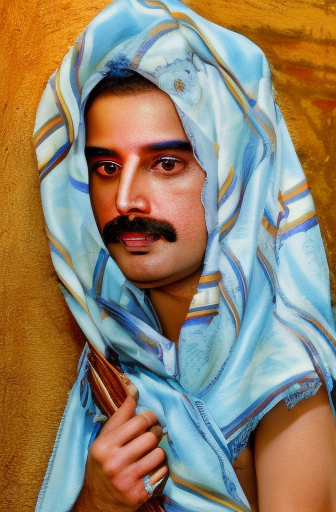

In [9]:
prompt = "a photo of sks face, best quality, extremely detailed, 4k, hdr, super resolution"
generator = torch.Generator(device="cpu").manual_seed(13356)

output = pipe(
    prompt,
    canny_image,
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality",
    generator=generator,
    num_inference_steps=20,
)

output.images[0]

## Controlnet для Stable Diffusion

In [10]:
controlnet = ControlNetModel.from_pretrained("lllyasviel/sd-controlnet-canny",
                                             torch_dtype=torch.float16)

pipe = StableDiffusionControlNetPipeline.from_pretrained(
    "/kaggle/input/sd1-5/output",
    controlnet=controlnet,
    torch_dtype=torch.float16)
pipe.scheduler = UniPCMultistepScheduler.from_config(pipe.scheduler.config)
pipe.enable_model_cpu_offload()
pipe.enable_xformers_memory_efficient_attention()

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

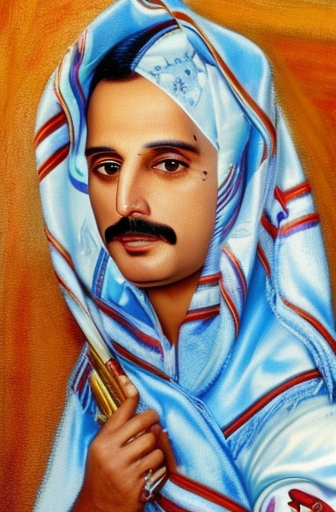

In [11]:
prompt = "a photo of sks face, best quality, extremely detailed, 4k, hdr, super resolution"
generator = torch.Generator(device="cpu").manual_seed(13356)

output = pipe(
    prompt,
    canny_image,
    negative_prompt="monochrome, lowres, bad anatomy, worst quality, low quality",
    generator=generator,
    num_inference_steps=20,
)

output.images[0]